# Yelp Dataset Quiz Notebook (for Prof Q&A)

This notebook is designed to **prove dataset understanding quickly** during a discussion/quiz.

**Questions:**
- How many users / businesses / reviews / tips / checkins?
- How many *restaurants* are there? Which cities dominate?
- How sparse are user–restaurant interactions?
- Do users mostly dine nearby? (using a **proxy**: distance from user's *visited-restaurant centroid*)
- What are typical travel distances (median / p90)?
- How many users are “local” vs “exploratory” (simple mobility stats)?

> **Important limitation:** Yelp Open Dataset does not contain users' true home GPS. “Nearby dining” is estimated from the **centroid of visited restaurants** per user.


## 0) Setup

In [1]:

# Core
import os, json, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pd.set_option("display.max_columns", 200)
# pd.set_option("display.width", 160)


## 1) Configure file paths (edit these)

In [2]:
BASE_DIR = Path(r"C:\Users\lebro\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset")

FILES = {
    "user": BASE_DIR / "yelp_academic_dataset_user.json",
    "business": BASE_DIR / "yelp_academic_dataset_business.json",
    "review": BASE_DIR / "yelp_academic_dataset_review.json",
    "tip": BASE_DIR / "yelp_academic_dataset_tip.json",
    "checkin": BASE_DIR / "yelp_academic_dataset_checkin.json",
}

for k, p in FILES.items():
    print(k, "->", p, "| exists:", p.exists())

user -> C:\Users\lebro\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_user.json | exists: True
business -> C:\Users\lebro\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_business.json | exists: True
review -> C:\Users\lebro\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_review.json | exists: True
tip -> C:\Users\lebro\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_tip.json | exists: True
checkin -> C:\Users\lebro\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_checkin.json | exists: True


## 2) Memory-safe JSONL loader (recommended)

In [3]:

def load_jsonl_selected(path: Path, keys=None, nrows=None, show_progress_every=200000):
    """Load a JSON Lines file by streaming line-by-line.
    - keys: list of keys to keep (None = keep all keys)
    - nrows: stop after nrows (None = load all)
    """
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            obj = json.loads(line)
            if keys is not None:
                obj = {k: obj.get(k, None) for k in keys}
            rows.append(obj)
            if show_progress_every and i % show_progress_every == 0:
                print(f"Loaded {i:,} lines from {path.name}")
            if nrows is not None and i >= nrows:
                break
    return pd.DataFrame(rows)

def df_overview(df: pd.DataFrame, name: str):
    print(f"\n=== {name} ===")
    print(df.shape)
    display(df.head(3))
    display(df.describe(include='all').T.head(20))
    miss = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
    display(pd.DataFrame({"missing_%": miss}).head(20))


## 3) Load datasets (use sampling first, then scale up)

## Why I set `N_USER`, `N_REVIEW`, `N_TIP` limits (sampling rationale)

The Yelp Open Dataset files (especially `review.json`) are very large, and loading the full dataset into memory can cause slowdowns or crashes during exploratory analysis.  
To keep the notebook **stable and reproducible**, I initially load a **fixed-size sample** using `nrows`:

- `N_USER = 100,000`
- `N_REVIEW = 200,000`
- `N_TIP = 200,000`
- `N_CHECKIN = None` (checkin file is relatively small, so it can be loaded fully)

### What this sampling is used for
This sample is used to:
- validate the preprocessing pipeline (joins, filtering restaurants, distance calculations)
- quickly inspect distributions (review counts, sparsity, city coverage)
- prototype “quiz answers” (e.g., nearby dining stats, mobility proxies) without waiting long runtimes

### Important note about representativeness
Because `user.json` and `review.json` are sampled independently, some users appearing in the sampled reviews may not appear in the sampled user table.  
This is expected for debugging/prototyping, and does not affect analysis that relies only on `review + business` joins.

### How I will scale to the full dataset
After the pipeline is verified on the sample, I will:
1. remove `nrows` limits (or stream the files in chunks), and  
2. cache the processed restaurant-only review table (e.g., Parquet) for full-scale modelling and evaluation.

This approach ensures early-stage correctness and prevents memory issues, while still supporting full-dataset results for final experiments.

In [4]:

# Start small to validate pipeline, then increase N_* gradually.
N_USER   = 100000     # your current sample size
N_REVIEW = 200000     # raise when ready (reviews is largest)
N_TIP    = 200000     # optional
N_CHECKIN = None      # checkin file is smaller; can load all

# Keys we actually use (keeps memory lower)
USER_KEYS = ["user_id", "name", "review_count", "yelping_since", "useful", "funny", "cool", "elite", "fans", "average_stars"]
BUS_KEYS  = ["business_id", "name", "city", "state", "latitude", "longitude", "stars", "review_count", "is_open", "categories"]
REVIEW_KEYS = ["review_id", "user_id", "business_id", "stars", "useful", "funny", "cool", "date"]

user = load_jsonl_selected(FILES["user"], keys=USER_KEYS, nrows=N_USER)
business = load_jsonl_selected(FILES["business"], keys=BUS_KEYS, nrows=None)  # business is manageable
review = load_jsonl_selected(FILES["review"], keys=REVIEW_KEYS, nrows=N_REVIEW)

tip = load_jsonl_selected(FILES["tip"], keys=["user_id","business_id","date","compliment_count"], nrows=N_TIP) if FILES["tip"].exists() else None
checkin = load_jsonl_selected(FILES["checkin"], keys=["business_id","date"], nrows=N_CHECKIN) if FILES["checkin"].exists() else None

df_overview(user, "user")
df_overview(business, "business")
df_overview(review, "review")
if tip is not None: df_overview(tip, "tip")
if checkin is not None: df_overview(checkin, "checkin")


Loaded 200,000 lines from yelp_academic_dataset_review.json
Loaded 200,000 lines from yelp_academic_dataset_tip.json

=== user ===
(100000, 10)


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,fans,average_stars
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,267,3.91
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...",3138,3.74
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013",52,3.32


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,100000,100000,qVc8ODYU5SZjKXVBgXdI7w,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,100000,15236,Michael,922,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_count,100000.0,NaN,NaN,NaN,92.6335,235.343251,0.0,10.0,27.0,80.0,17473.0
yelping_since,100000,99963,2013-11-12 18:15:32,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
useful,100000.0,NaN,NaN,NaN,217.2179,1635.731828,0.0,7.0,26.0,96.0,206296.0
funny,100000.0,NaN,NaN,NaN,91.4065,1058.049858,0.0,1.0,5.0,24.0,185823.0
cool,100000.0,NaN,NaN,NaN,131.09871,1401.437743,0.0,1.0,7.0,31.0,195814.0
elite,100000,734,,80138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fans,100000.0,NaN,NaN,NaN,7.47896,57.493123,0.0,0.0,1.0,4.0,12497.0
average_stars,100000.0,NaN,NaN,NaN,3.853158,0.681401,1.0,3.53,3.91,4.28,5.0


,missing_%
user_id,0.0
name,0.0
review_count,0.0
yelping_since,0.0
useful,0.0
funny,0.0
cool,0.0
elite,0.0
fans,0.0
average_stars,0.0



=== business ===
(150346, 10)


...

,missing_%
user_id,0.0
business_id,0.0
date,0.0
compliment_count,0.0



=== checkin ===
(131930, 2)


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"


,count,unique,top,freq
business_id,131930,131930,---kPU91CF4Lq2-WlRu9Lw,1
date,131930,131930,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020...",1


,missing_%
business_id,0.0
date,0.0


## 4) Basic dataset facts 

In [5]:

facts = {
    "users_loaded": len(user),
    "businesses_total": len(business),
    "reviews_loaded": len(review),
    "tips_loaded": None if tip is None else len(tip),
    "checkins_loaded": None if checkin is None else len(checkin),
    "unique_users_in_reviews": review["user_id"].nunique(),
    "unique_businesses_in_reviews": review["business_id"].nunique(),
}
pd.DataFrame([facts]).T.rename(columns={0:"value"})


,value
users_loaded,100000
businesses_total,150346
reviews_loaded,200000
tips_loaded,200000
checkins_loaded,131930
unique_users_in_reviews,143686
unique_businesses_in_reviews,11451


## What this table is showing

This table is a quick “dataset summary” of what I have loaded into memory in this notebook.

- **users_loaded (100,000)**  
  I loaded **100,000 user profiles** from the user dataset (this is a sample, not necessarily all users).

- **businesses_total (150,346)**  
  I loaded **all 150,346 businesses** from the business dataset.

- **reviews_loaded (200,000)**  
  I loaded **200,000 reviews** from the review dataset (also a sample).

- **tips_loaded (200,000)**  
  I loaded **200,000 tip posts** (short user messages) from the tip dataset (sample).

- **checkins_loaded (131,930)**  
  I loaded **131,930 check-in records** (this file is smaller so it may be fully loaded).

- **unique_users_in_reviews (143,686)**  
  Within the **200,000 reviews** I loaded, there are **143,686 different users** who wrote them.  
  (This can be larger than `users_loaded` because the review sample may include users not included in the 100k user sample.)

- **unique_businesses_in_reviews (11,451)**  
  Within the **200,000 reviews** I loaded, there are reviews for **11,451 different businesses**.

### In short
I loaded a **sample of users/reviews/tips** for faster testing, but I loaded **all businesses**.  
This summary tells me how big my working data is and how many unique users and businesses appear in the reviews I’m currently using.

## 5) Restaurant filtering + top cities/states

In [6]:

def is_restaurant(categories):
    if categories is None or (isinstance(categories, float) and np.isnan(categories)):
        return False
    return "Restaurants" in categories

business["is_restaurant"] = business["categories"].apply(is_restaurant)

restaurants = business[business["is_restaurant"]].copy()
print("Restaurants:", len(restaurants), "/", len(business))

# Top cities by restaurant count
top_cities = restaurants["city"].value_counts().head(15).rename_axis("city").reset_index(name="restaurant_count")
display(top_cities)

# Top states by restaurant count
top_states = restaurants["state"].value_counts().head(10).rename_axis("state").reset_index(name="restaurant_count")
display(top_states)


Restaurants: 52268 / 150346


,city,restaurant_count
0,Philadelphia,5852
1,Tampa,2960
2,Indianapolis,2862
3,Nashville,2502
4,Tucson,2466
5,New Orleans,2259
6,Edmonton,2166
7,Saint Louis,1790
8,Reno,1286
9,Boise,847


,state,restaurant_count
0,PA,12641
1,FL,8731
2,TN,4352
3,MO,4247
4,IN,4150
5,LA,3640
6,NJ,3341
7,AZ,2671
8,AB,2410
9,NV,1673


## What this output is showing

This section answers: **“How many restaurants are in the Yelp business dataset, and where are they mostly located?”**

### 1) Restaurants count
- **Restaurants: 52,268 / 150,346**
- Meaning: Out of **150,346 total businesses** in the dataset, **52,268 are tagged as “Restaurants”** (based on the `categories` field).

### 2) Top cities with the most restaurants
The first table lists the **cities that have the highest number of restaurant businesses** in this dataset.
For example:
- **Philadelphia: 5,852 restaurants**
- **Tampa: 2,960**
- **Indianapolis: 2,862**
- **Nashville: 2,502**
…and so on.

This helps show which cities are most represented (so the dataset is **not evenly spread** across all cities).

### 3) Top states with the most restaurants
The second table shows the **states with the highest number of restaurant businesses** in the dataset.
For example:
- **PA (Pennsylvania): 12,641 restaurants**
- **FL (Florida): 8,731**
- **TN (Tennessee): 4,352**
- **MO (Missouri): 4,247**
…and so on.

### In short
- The dataset contains **~52k restaurant businesses**.
- Most restaurant entries come from a few major cities/states (e.g., **Philadelphia / PA**), meaning the dataset is **city/state concentrated** rather than evenly distributed.


## 6) Join reviews with restaurants (core interaction table)

In [7]:

reviews_r = review.merge(
    restaurants[["business_id","city","state","latitude","longitude","stars","review_count"]],
    on="business_id",
    how="inner",
)
print("Reviews on restaurants:", len(reviews_r), "out of", len(review))
display(reviews_r.head())


Reviews on restaurants: 144424 out of 200000


,review_id,user_id,business_id,stars_x,useful,funny,cool,date,city,state,latitude,longitude,stars_y,review_count
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,2018-07-07 22:09:11,North Wales,PA,40.210196,-75.223639,3.0,169
1,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,2014-02-05 20:30:30,Tucson,AZ,32.207233,-110.980864,3.5,47
2,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,2015-01-04 00:01:03,Philadelphia,PA,40.079848,-75.025080,4.0,181
3,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,2017-01-14 20:54:15,New Orleans,LA,29.962102,-90.087958,4.0,32
4,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,2,1,2015-09-23 23:10:31,Philadelphia,PA,39.938013,-75.148131,4.0,273


## What this step is doing

This step creates the **main table we use for analysis and recommendation** by combining two datasets:

- **Reviews dataset** = “Who reviewed what, what rating they gave, and when”
- **Restaurants dataset** = “Where the restaurant is (city/state/latitude/longitude) and its overall stats”

### What “join reviews with restaurants” means
We match each review to its restaurant using the shared key:
- `business_id`

We use an **inner join**, meaning:
- We only keep reviews where the `business_id` is found in the restaurant list.
- So reviews for non-restaurant businesses (e.g., salons, gyms, shops) are removed.

### What the result tells us
It prints:

- **“Reviews on restaurants: 144,424 out of 200,000”**

Meaning:
- From the **200,000 reviews** we loaded (sample),
- **144,424** of them are reviews for businesses that are tagged as **Restaurants**.

### What `reviews_r` contains now
Each row is now a “complete interaction record” like:

- User: `user_id`
- Restaurant: `business_id`
- User’s rating for that visit: `stars_x` (the review rating)
- Review feedback: `useful`, `funny`, `cool`
- Time: `date`
- Restaurant location: `city`, `state`, `latitude`, `longitude`
- Restaurant overall info: `stars_y` (overall average rating), `review_count`

### In short
This step filters the review data down to **restaurant reviews only** and enriches them with restaurant details, so we can later analyze things like:
- where users eat,
- how far they travel,
- and build recommendation models from user–restaurant interactions.

## 7) Sparsity + activity distributions (common quiz topics)

Unique users in restaurant reviews: 108,528
Unique restaurants reviewed:        4,415
Interactions (reviews):            144,424
Interaction matrix sparsity:       0.999699 (closer to 1 = very sparse)


,unique_restaurants_reviewed
count,108528.000000
mean,1.310123
std,1.082639
min,1.000000
50%,1.000000
75%,1.000000
90%,2.000000
95%,3.000000
99%,6.000000
max,53.000000


,unique_users_reviewed
count,4415.000000
mean,32.204983
std,67.131338
min,1.000000
50%,12.000000
75%,33.000000
90%,76.000000
95%,124.000000
99%,295.440000
max,1833.000000


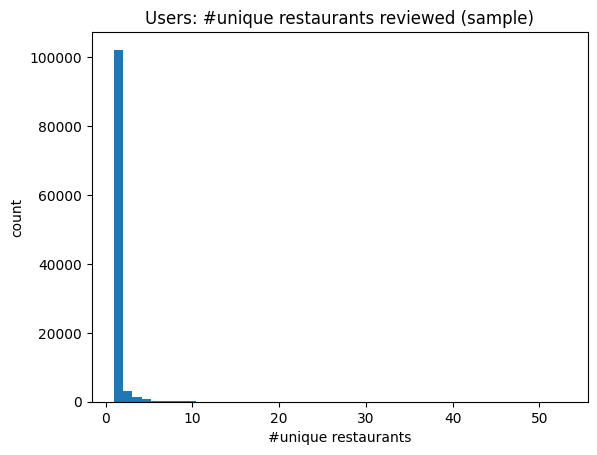

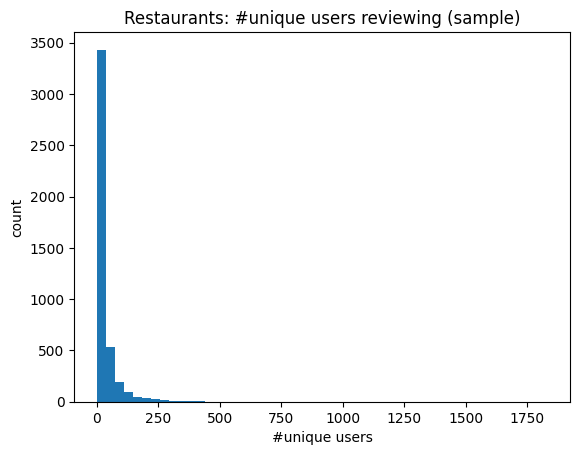

In [8]:

n_users = reviews_r["user_id"].nunique()
n_items = reviews_r["business_id"].nunique()
n_interactions = len(reviews_r)

sparsity = 1 - (n_interactions / (n_users * n_items))
print(f"Unique users in restaurant reviews: {n_users:,}")
print(f"Unique restaurants reviewed:        {n_items:,}")
print(f"Interactions (reviews):            {n_interactions:,}")
print(f"Interaction matrix sparsity:       {sparsity:.6f} (closer to 1 = very sparse)")

user_deg = reviews_r.groupby("user_id")["business_id"].nunique().rename("unique_restaurants_reviewed")
item_deg = reviews_r.groupby("business_id")["user_id"].nunique().rename("unique_users_reviewed")

display(user_deg.describe(percentiles=[.5,.75,.9,.95,.99]).to_frame())
display(item_deg.describe(percentiles=[.5,.75,.9,.95,.99]).to_frame())

plt.figure()
plt.hist(user_deg.values, bins=50)
plt.title("Users: #unique restaurants reviewed (sample)")
plt.xlabel("#unique restaurants")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(item_deg.values, bins=50)
plt.title("Restaurants: #unique users reviewing (sample)")
plt.xlabel("#unique users")
plt.ylabel("count")
plt.show()


## What this section shows

This section explains **how the Yelp restaurant review data is distributed** — basically, *who reviewed what*, and how “dense” or “sparse” the user–restaurant data is.

---

### 1) Big picture counts (from the restaurant-review table)
- **Unique users in restaurant reviews: 108,528**  
  → In this sample, **108,528 different people** wrote at least one restaurant review.

- **Unique restaurants reviewed: 4,415**  
  → These reviews mention **4,415 different restaurants**.

- **Interactions (reviews): 144,424**  
  → Total **144,424 review records** (each row = one user reviewing one restaurant).

---

### 2) “Interaction matrix sparsity: 0.999699” (what that means)
Think of a big table:
- rows = users  
- columns = restaurants  
- a cell is filled only if a user reviewed that restaurant.

**Sparsity = 0.999699** means:
- Almost all cells are empty.
- Users review only a tiny number of restaurants compared to the total number of restaurants.

✅ In simple terms: **most users only review a few restaurants, and most restaurants are reviewed by a small portion of users.**

---

### 3) User behaviour: “How many restaurants does a typical user review?”
The first stats table (`unique_restaurants_reviewed`) shows:
- **50% (median) = 1**  
  → Half of users reviewed **only 1 restaurant** in this sample.
- **90% = 2**  
  → 90% of users reviewed **2 restaurants or fewer**.
- **99% = 6**  
  → 99% reviewed **6 restaurants or fewer**.
- **max = 53**  
  → A very small number of users are “super active” and reviewed many restaurants.

The top histogram shows the same thing visually:
- Most users are clustered at **1–2 restaurants**.
- A small tail goes to higher values.

---

### 4) Restaurant behaviour: “How many users review a typical restaurant?”
The second stats table (`unique_users_reviewed`) shows:
- **median = 12**  
  → A typical restaurant has **about 12 different users** reviewing it (in this sample).
- **75% = 33**  
  → 75% of restaurants have **33 reviewers or fewer**.
- **95% = 124**
- **max = 1,833**  
  → A few restaurants are extremely popular and get lots of reviews.

The bottom histogram shows:
- Most restaurants have relatively few reviewers.
- A few restaurants have very large reviewer counts (long tail).

---

### In short
- The data is **very sparse**: users review only a few restaurants.
- Most users are “light users” (often only 1 restaurant reviewed in the sample).
- Some restaurants are “popular hubs” with many reviewers, but most are not.

This sparsity is normal for recommendation datasets and explains why models like **GMF / MLP / NeuCF** are used (they learn patterns from sparse interactions).

## 8) Nearby dining analysis (proxy using user centroid)

,user_id,business_id,dist_km,city,state
0,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,14.815896,North Wales,PA
1,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,1701.005004,Tucson,AZ
2,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,0.000000,Philadelphia,PA
3,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,0.140648,New Orleans,LA
4,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,0.000000,Philadelphia,PA


,median_km,p75_km,p90_km,max_km
count,108528.000000,108528.000000,108528.000000,108528.000000
mean,7.269716,10.486467,13.943863,16.999117
std,79.860966,97.664804,124.147222,153.393579
min,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
90%,2.120577,3.078887,3.492497,3.686827
95%,6.249685,8.693648,10.373449,11.448933
99%,25.376860,381.235837,555.838439,680.866736
max,2008.026829,3775.072602,3775.209820,3951.743845


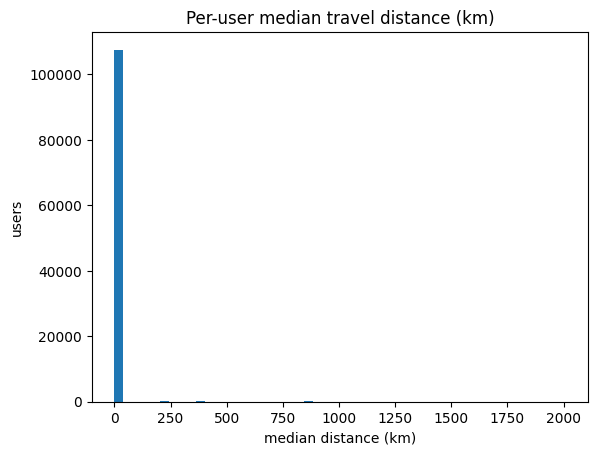

,threshold_km,visits_within_%,users_median_within_%
0,1,72.46,87.29
1,3,80.81,91.51
2,5,85.44,93.89
3,10,91.82,97.06


In [9]:

def haversine_km(lat1, lon1, lat2, lon2):
    # radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    R = 6371.0
    return R * c

# 1) Compute user centroid from visited restaurant coordinates
centroids = (
    reviews_r.groupby("user_id")
    .agg(
        centroid_lat=("latitude","median"),   # median is robust to outliers
        centroid_lon=("longitude","median"),
        visits=("business_id","count"),
        unique_places=("business_id","nunique"),
    )
    .reset_index()
)

# 2) Attach centroid back to each visit and compute distance
tmp = reviews_r.merge(centroids[["user_id","centroid_lat","centroid_lon"]], on="user_id", how="left")
tmp["dist_km"] = haversine_km(tmp["centroid_lat"], tmp["centroid_lon"], tmp["latitude"], tmp["longitude"])

display(tmp[["user_id","business_id","dist_km","city","state"]].head())

# 3) Per-user distance stats
user_dist = (
    tmp.groupby("user_id")["dist_km"]
    .agg(median_km="median", p75_km=lambda s: np.quantile(s, 0.75), p90_km=lambda s: np.quantile(s, 0.90), max_km="max")
    .reset_index()
)

display(user_dist.describe(percentiles=[.5,.75,.9,.95,.99]))

plt.figure()
plt.hist(user_dist["median_km"].values, bins=50)
plt.title("Per-user median travel distance (km)")
plt.xlabel("median distance (km)")
plt.ylabel("users")
plt.show()

# 4) Answer: “How many users dine nearby?” using thresholds
thresholds = [1, 3, 5, 10]  # km
summary = []
for t in thresholds:
    # % of visits within t km
    visit_ratio = (tmp["dist_km"] <= t).mean()
    # % of users whose median visit distance <= t km
    user_ratio = (user_dist["median_km"] <= t).mean()
    summary.append({"threshold_km": t, "visits_within_%": round(visit_ratio*100,2), "users_median_within_%": round(user_ratio*100,2)})

pd.DataFrame(summary)


## What this section shows

This section answers: **“How far do users usually travel to eat?”**  
Since Yelp does not give a user’s real home location, we estimate a user’s “usual area” using a proxy:

✅ **User centroid (proxy home area)** = the middle (median) location of the restaurants the user has reviewed.  
Then we measure the distance from that centroid to each restaurant they reviewed.

---

## 1) The table at the top (example rows)
Each row is one review + a distance:

- `user_id` = who wrote the review  
- `business_id` = which restaurant  
- `dist_km` = how far that restaurant is from the user’s “usual area” (centroid)  
- `city/state` = where that restaurant is

So this is basically: **“For this user, this restaurant is X km away from where they typically dine.”**

---

## 2) The statistics table (per-user travel distance summary)

This table summarizes travel distance **per user** (not per review).  
For every user, we calculate:

- `median_km` = the user’s *typical* travel distance (middle value)
- `p75_km` / `p90_km` = their higher-end travel distances
- `max_km` = the farthest they went

Key takeaways from your numbers:

- **Median (50%) = 0.00 km**
  - This means **at least half of users have a median travel distance of ~0 km**.
  - In practice, this usually happens because many users only reviewed **1 restaurant** in the sample, so their centroid equals that restaurant → distance becomes 0.

- **90% of users have median travel distance ≤ ~2.12 km**
- **95% ≤ ~6.25 km**
- **99% ≤ ~25.38 km**

- The very large max values (hundreds/thousands km) indicate **outliers**:
  - users who reviewed restaurants in very different cities (travel / moving / data noise).

---

## 3) The histogram (Per-user median travel distance)
This chart shows the same thing visually:

- A huge spike near **0 km** (most users appear “local” in the sample)
- A long tail (a small number travel far)

---

## 4) “How many users dine nearby?” (threshold table)

This table gives two “nearby” perspectives for different distance thresholds:

### `visits_within_%`
Out of all restaurant reviews (visits), the % that are within X km of the user centroid:

- **Within 1 km: 72.46% of visits**
- **Within 3 km: 80.81% of visits**
- **Within 5 km: 85.44% of visits**
- **Within 10 km: 91.82% of visits**

### `users_median_within_%`
The % of users whose *typical* (median) restaurant distance is within X km:

- **Within 1 km: 87.29% of users**
- **Within 3 km: 91.51% of users**
- **Within 5 km: 93.89% of users**
- **Within 10 km: 97.06% of users**

✅ In simple terms:
- Most reviews happen **near where the user usually eats** (based on the centroid proxy).
- Most users are “mostly local” at common thresholds like 3–5 km.

---

## Important caveat
Because many users only reviewed **1–2 restaurants** in the sample, the centroid method can produce lots of **0 km** medians.  
A common fix is to compute mobility stats only for users with at least e.g. **5 or 10 unique restaurants**, so the centroid is meaningful.

## 9) Simple mobility labeling (Local vs Explorer-style)

In [22]:
# Robust mobility labeling (avoid the “threshold = 0 km” issue)
# Yelp does not provide a user's real home location, so distances are based on a centroid proxy.
# To make mobility meaningful, we only classify users with enough unique restaurants.

MIN_PLACES = 5  # users must have reviewed at least this many unique restaurants to be classified
q = 0.75        # top 25% (by mobility metric) labelled as "Explorer"

# Users eligible for mobility stats
eligible_users = centroids.loc[centroids["unique_places"] >= MIN_PLACES, "user_id"]
user_dist_el = user_dist[user_dist["user_id"].isin(eligible_users)].copy()

print(f"Eligible users (unique_places >= {MIN_PLACES}): {len(user_dist_el):,} / {len(user_dist):,}")

display(
    user_dist_el[["median_km","p75_km","p90_km","max_km"]]
    .describe(percentiles=[.5,.75,.9,.95,.99])
)

# Method 1 (recommended for research comparisons): percentile cut on median_km
thr_median = float(user_dist_el["median_km"].quantile(q))
print(f"Explorer threshold (median_km >= {q:.2f} quantile): {thr_median:.3f} km")

user_dist_el["mobility_class_median_q"] = np.where(user_dist_el["median_km"] >= thr_median, "Explorer", "Local")
display(user_dist_el["mobility_class_median_q"].value_counts().to_frame("count"))

# Optional: compare a few alternative definitions (interpretability vs robustness)
thr_p75 = float(user_dist_el["p75_km"].quantile(q))
thr_p90 = float(user_dist_el["p90_km"].quantile(q))

user_dist_el["mobility_class_p75_q"] = np.where(user_dist_el["p75_km"] >= thr_p75, "Explorer", "Local")
user_dist_el["mobility_class_p90_q"] = np.where(user_dist_el["p90_km"] >= thr_p90, "Explorer", "Local")

ABS_THR_KM = 5
user_dist_el["mobility_class_abs_median"] = np.where(user_dist_el["median_km"] > ABS_THR_KM, "Explorer", "Local")

summary = []
for col in ["mobility_class_median_q","mobility_class_p75_q","mobility_class_p90_q","mobility_class_abs_median"]:
    vc = user_dist_el[col].value_counts()
    summary.append({
        "method": col,
        "Local": int(vc.get("Local", 0)),
        "Explorer": int(vc.get("Explorer", 0)),
        "Explorer_%": round(100 * vc.get("Explorer", 0) / len(user_dist_el), 2),
    })
display(pd.DataFrame(summary).sort_values("Explorer_%", ascending=False))

# Show example users (most exploratory / most local by median_km)
display(user_dist_el.sort_values("median_km", ascending=False).head(10))
display(user_dist_el.sort_values("median_km", ascending=True).head(10))

Eligible users (unique_places >= 5): 1,825 / 108,528


,median_km,p75_km,p90_km,max_km
count,1825.000000,1825.000000,1825.000000,1825.000000
mean,10.222794,50.780218,133.920449,233.963963
std,64.233945,241.712711,372.657956,576.586642
min,0.024921,0.256010,0.470849,0.501883
50%,3.793012,7.971752,13.007519,17.245823
75%,7.642064,13.875008,23.953633,32.656942
90%,11.948509,23.536875,471.032996,1090.246113
95%,16.134040,37.159047,962.433112,1679.333444
99%,25.413712,1294.721252,1750.948195,2766.513417
max,1304.872935,3775.072602,3775.209820,3951.198638


Explorer threshold (median_km >= 0.75 quantile): 7.642 km


,count
mobility_class_median_q,
Local,1368
Explorer,457


,method,Local,Explorer,Explorer_%
3,mobility_class_abs_median,1091,734,40.22
0,mobility_class_median_q,1368,457,25.04
1,mobility_class_p75_q,1368,457,25.04
2,mobility_class_p90_q,1368,457,25.04


,user_id,median_km,p75_km,p90_km,max_km,mobility_class,mobility_class_median_q,mobility_class_p75_q,mobility_class_p90_q,mobility_class_abs_median
33336,IkLdv0dFGfRJrtFVJYJnLg,1304.872935,2673.200705,2674.035585,2679.224585,Explorer,Explorer,Explorer,Explorer,Explorer
15272,82dCHyU-ANOgdhxUgZsUeg,1273.269861,2533.520598,2536.945690,2539.229085,Explorer,Explorer,Explorer,Explorer,Explorer
100342,v9kNOSkmtpwAESHKtcuNjA,963.720106,2537.761575,2541.051593,2543.244937,Explorer,Explorer,Explorer,Explorer,Explorer
66252,b2oS5BgjMigy0_5oV4R-4g,805.078924,806.164818,2146.946528,3040.801001,Explorer,Explorer,Explorer,Explorer,Explorer
65726,akUC5qP68u0_frTwHLl61w,741.778990,762.592186,792.584672,792.884595,Explorer,Explorer,Explorer,Explorer,Explorer
27744,FOjWOTVEQyjChNghH-JoFQ,735.211084,1293.077136,1294.851386,1296.034219,Explorer,Explorer,Explorer,Explorer,Explorer
15851,8MKygqfspKqG2-X9ycR-Ow,731.008122,1295.240446,1297.095877,1298.332832,Explorer,Explorer,Explorer,Explorer,Explorer
32895,ITa3vh5ERI90G_WP4SmGUQ,551.969045,556.597037,891.552835,1226.320126,Explorer,Explorer,Explorer,Explorer,Explorer
4510,1f3lYkwVQzgbfrkYeAW5uQ,540.195862,561.747228,886.623849,1206.990795,Explorer,Explorer,Explorer,Explorer,Explorer
61104,Yygufhb_Nk2_GZOJmIcEJA,469.974573,741.283121,1836.101699,2840.484093,Explorer,Explorer,Explorer,Explorer,Explorer


,user_id,median_km,p75_km,p90_km,max_km,mobility_class,mobility_class_median_q,mobility_class_p75_q,mobility_class_p90_q,mobility_class_abs_median
71957,eQB-zeNwKOGk3F1xLQDp5g,0.024921,2.258231,3.100849,3.788643,Explorer,Local,Local,Local,Local
58858,XhrlkiNB867EmtYuDTcq7Q,0.058607,2.237576,577.328467,960.722395,Explorer,Local,Local,Explorer,Local
72589,eohT1wbxtTQ8wgOal2uaFQ,0.071118,0.934102,1.608610,2.058282,Explorer,Local,Local,Local,Local
81007,jklCtvLWbkuoBiw60i1g3g,0.094276,0.692024,15.187656,24.851411,Explorer,Local,Local,Local,Local
26008,EMJjstNBGfIlJbooOO1i_g,0.096481,2.455632,14.680946,27.173854,Explorer,Local,Local,Local,Local
37769,LNEyUWtTpvvMhp9KssJPIg,0.117139,4.584029,15.548696,25.028112,Explorer,Local,Local,Local,Local
336,-CTVKe6KxXl2hPjFKHhxaQ,0.124094,2.483478,2.577735,2.640573,Explorer,Local,Local,Local,Local
6986,35to6xbEZjGRy8asMVJ-YA,0.130951,0.256010,2.180775,3.463952,Explorer,Local,Local,Local,Local
104986,xttYXDJT9JokoiSTpirmjQ,0.132962,1.657534,16.103911,25.734830,Explorer,Local,Local,Local,Local
18521,9wvR3a-jGWmth9rgttgU2w,0.137995,8.377817,21.625207,36.348531,Explorer,Local,Local,Local,Local


## Mobility results (eligible users) — what this output shows in simple terms

### 1) How many users can be analysed for mobility
- **Eligible users (unique_places ≥ 5): 1,825 / 108,528**
- Meaning: Out of all users who appear in restaurant reviews, only **1,825 users** reviewed at least **5 different restaurants** (in the current sample).
- This matters because users with very few reviews often produce **0 km** distances (not meaningful for mobility).

---

### 2) What the distance statistics mean (for eligible users)
These numbers describe how far eligible users typically travel from their “usual area”.

Because Yelp does not provide a real home location, I estimate a user’s “usual area” using a **centroid proxy**:
- **User centroid** = the median location of restaurants the user reviewed  
- **Travel distance** = distance from centroid to each restaurant reviewed

Key takeaways (from the table):
- **Typical user (median of median_km) ≈ 3.79 km**
  - A typical eligible user usually eats around **~4 km** from their usual area.
- **75th percentile of median_km = 7.64 km**
  - 75% of eligible users have a typical travel distance **≤ 7.64 km**
- **90th percentile of median_km ≈ 11.95 km**
  - 90% of eligible users have a typical travel distance **≤ ~12 km**

⚠️ Note: there are extreme outliers (some users show distances in the **hundreds or thousands of km**).  
These likely represent users who reviewed restaurants across multiple cities/states (travel/moving) and can distort averages.

---

### 3) Explorer vs Local classification (percentile-based rule)
I used a simple and stable definition:
- **Explorer = top 25% most mobile users** (based on median travel distance among eligible users)
- **Local = the remaining 75%**

This produced:
- **Explorer threshold (median_km ≥ 7.642 km)**  
- **Local: 1,368 users**
- **Explorer: 457 users**

This result makes sense because using the **75th percentile cutoff** is designed to classify about **25%** as Explorers.

---

### 4) Comparing different mobility rules (why results differ)
I tested multiple rules and they produce different Explorer proportions:

- **Percentile-based rules (median/p75/p90 with 75th percentile cutoff)**  
  → Always around **25% Explorers** by design (stable and balanced)

- **Absolute rule (median_km > 5 km)**  
  → Labels more users as Explorer (**~40% Explorers**), because it uses a real-world distance threshold

✅ Conclusion:
- **Percentile rules** are useful when I want a consistent “top group” for comparisons.
- **Absolute km rules** are more intuitive but depend heavily on the chosen threshold (3km vs 5km vs 10km).
- Outliers should be handled or at least mentioned, because very large travel distances can skew mobility interpretation.

---

### Short takeaway
After filtering to users with ≥ 5 unique restaurants, mobility patterns become meaningful:
- Most eligible users are relatively local (typical travel distance around a few km),
- A smaller group travels farther (Explorers),
- The exact Explorer proportion depends on the definition used.

In [10]:
# A simple interpretable proxy:
# - Local: lower median distance
# - Explorer: higher median distance

# Choose a threshold based on distribution (example: 75th percentile of median distances)
thr = float(user_dist["median_km"].quantile(0.75))
print("Explorer threshold (median_km >=):", round(thr, 3), "km")

user_dist["mobility_class"] = np.where(user_dist["median_km"] >= thr, "Explorer", "Local")
display(user_dist["mobility_class"].value_counts().to_frame("count"))

# Show a few examples
display(user_dist.sort_values("median_km", ascending=False).head(10))
display(user_dist.sort_values("median_km", ascending=True).head(10))


Explorer threshold (median_km >=): 0.0 km


,count
mobility_class,
Explorer,108528


,user_id,median_km,p75_km,p90_km,max_km,mobility_class
14453,7YUWpktY_1iIjNr2fXGOQA,2008.026829,2027.129047,2038.590378,2046.231265,Explorer
13122,6jz_Yr6_AP2WWLbj9gGDpA,1998.613380,2016.808802,2027.726055,2035.004224,Explorer
62803,Zz7wvkHp0mT8dSLgz_lgog,1995.706499,2013.391375,2024.002301,2031.076252,Explorer
36699,KhOTFCZAF5bAKpQTpigHHw,1994.481623,2012.220256,2022.863435,2029.958888,Explorer
61432,ZBLZIOrO3DZJzDFlFO-bJw,1993.632541,2011.998854,2023.018641,2030.365166,Explorer
102897,wgDQzzIDBDofR4SHjnjP7w,1991.530990,2009.568178,2020.390491,2027.605366,Explorer
76417,h1wKEXFcMAMikSFsJyisCA,1991.355103,2010.047580,2021.263066,2028.740057,Explorer
98410,u1_ZtiXzSp55JuOS7PjhYw,1991.347877,2009.525306,2020.431763,2027.702734,Explorer
67018,bURBDO2lgSrxnth2P7v3Gw,1990.459526,2008.422443,2019.200193,2026.385359,Explorer
87786,nm6AiEXKLh3P2TG4sf2vHw,1989.847543,2007.801768,2018.574303,2025.755993,Explorer


,user_id,median_km,p75_km,p90_km,max_km,mobility_class
0,---2PmXbF47D870stH1jqA,0.0,0.0,0.0,0.0,Explorer
69110,cjIKPATBv91u8ftXzg8ozA,0.0,0.0,0.0,0.0,Explorer
69109,cjBlBQQbSDTFdf29-5JYRg,0.0,0.0,0.0,0.0,Explorer
69108,cjAvURfwsm-L6Ox9D4EqLg,0.0,0.0,0.0,0.0,Explorer
69107,cjA-i8OpvK_Lg9gjykPXMg,0.0,0.0,0.0,0.0,Explorer
69105,citr_fJB77KUHDkMkhpSxQ,0.0,0.0,0.0,0.0,Explorer
69104,citTKMQqjrBePwWWMv1e6A,0.0,0.0,0.0,0.0,Explorer
69103,ciq11SgiZfjGWST_DMZb9Q,0.0,0.0,0.0,0.0,Explorer
69102,cioA8RAZLufFlU8UcaBAqQ,0.0,0.0,0.0,0.0,Explorer
69101,cio1G2jhQ2gwHBXsfSkYcg,0.0,0.0,0.0,0.0,Explorer


Using median distance directly on all users makes the threshold collapse to 0 because many users only have 1–2 reviews, so the centroid proxy leads to 0 km distances. To make mobility meaningful, I either filter to users with enough visited restaurants, or use a more robust spread metric like p75 distance

## 10) Time coverage + leakage awareness

In [11]:

# Make sure review dates are datetime
reviews_r["date"] = pd.to_datetime(reviews_r["date"], errors="coerce")

print("Review date range:", reviews_r["date"].min(), "->", reviews_r["date"].max())
display(reviews_r["date"].isna().mean())

# Example: time-aware split per user (train on earlier, test on later)
# (This is a template; adapt for your modelling pipeline.)
def time_split_per_user(df, test_ratio=0.2, min_interactions=5):
    df = df.sort_values(["user_id","date"])
    parts = []
    for uid, g in df.groupby("user_id"):
        if len(g) < min_interactions:
            continue
        cut = int(len(g) * (1 - test_ratio))
        parts.append((g.iloc[:cut].assign(split="train"), g.iloc[cut:].assign(split="test")))
    if not parts:
        return df.assign(split="all")
    train = pd.concat([a for a,b in parts], ignore_index=True)
    test  = pd.concat([b for a,b in parts], ignore_index=True)
    return pd.concat([train, test], ignore_index=True)

split_df = time_split_per_user(reviews_r, test_ratio=0.2, min_interactions=10)
display(split_df["split"].value_counts())


Review date range: 2005-03-01 17:47:15 -> 2019-01-06 11:48:21


0.0

split
train    3682
test     1091
Name: count, dtype: int64

### What this section is checking
This section answers two questions:

1) **What time period does the review data cover?**  
2) **How can we split the data for training/testing without “cheating”?** (data leakage)

---

### 1) Time coverage (date range)
I convert the review `date` column into a proper datetime format, then check:

- **Earliest review:** 2005-03-01  
- **Latest review:** 2019-01-06  

So the (sampled) review data spans **~2005 to 2019**.

I also check for missing/invalid dates:

- Output `0.0` means **0% of dates are missing**, so all review dates were parsed correctly.

---

### 2) Why we care about “data leakage”
If we randomly mix reviews from all years into training and testing, the model might indirectly learn from “future” behaviour.  
For example, it could train on a user’s later reviews and then “predict” earlier ones, which is unrealistic.

To avoid this, I use a **time-aware split**:

✅ For each user:
- sort their reviews by date
- put the **earlier 80%** into **train**
- put the **later 20%** into **test**

This better simulates the real-world scenario:
> “Use a user’s past behaviour to predict what they will like next.”

---

### 3) What the split results mean
The split count shows:

- **train: 3,682 rows**
- **test: 1,091 rows**

These are the number of review records assigned to each split **after filtering users** with enough interactions (`min_interactions=10`).

In other words:
- Only users with at least 10 reviews are included for this time-based split,
- then their reviews are divided into train/test in chronological order.

---

### In short
- The review data covers **2005–2019** with no missing timestamps.
- I use a **time-aware train/test split per user** to reduce data leakage and make evaluation more realistic.

## 11) Prof-Quiz: one-click answers

In [23]:
def quick_answers(min_places=5):
    out = {}
    out["#users (loaded user table)"] = len(user)
    out["#businesses (all)"] = len(business)
    out["#restaurants"] = len(restaurants)
    out["#reviews (loaded)"] = len(review)
    out["#restaurant reviews (loaded)"] = len(reviews_r)

    # User activity (restaurant interactions)
    out["median unique restaurants per user"] = float(user_deg.median()) if len(user_deg) else None
    out["p90 unique restaurants per user"] = float(user_deg.quantile(0.9)) if len(user_deg) else None

    # Travel distance (all users) — may be 0-heavy due to low-history users
    out["median per-user median_km (all users)"] = float(user_dist["median_km"].median()) if len(user_dist) else None
    out["p90 per-user median_km (all users)"] = float(user_dist["median_km"].quantile(0.9)) if len(user_dist) else None

    # Travel distance (eligible users only) — more meaningful mobility proxy
    if "unique_places" in centroids.columns:
        eligible = centroids.loc[centroids["unique_places"] >= min_places, "user_id"]
        ud_el = user_dist[user_dist["user_id"].isin(eligible)]
        out[f"eligible users (unique_places >= {min_places})"] = int(len(ud_el))
        out[f"median of median_km (eligible)"] = float(ud_el["median_km"].median()) if len(ud_el) else None
        out[f"p90 of median_km (eligible)"] = float(ud_el["median_km"].quantile(0.9)) if len(ud_el) else None
    else:
        out[f"eligible users (unique_places >= {min_places})"] = None

    return pd.DataFrame([out]).T.rename(columns={0:"answer"})

quick_answers()

,answer
#users (loaded user table),100000.000000
#businesses (all),150346.000000
#restaurants,52268.000000
#reviews (loaded),200000.000000
#restaurant reviews (loaded),144424.000000
median unique restaurants per user,1.000000
p90 unique restaurants per user,2.000000
median per-user median_km (all users),0.000000
p90 per-user median_km (all users),2.120577
eligible users (unique_places >= 5),1825.000000


This table is a **quick cheat sheet** summarising the most important numbers from the data I loaded, so I can answer common questions instantly.

### Dataset size (what I currently loaded)
- **Users loaded:** 100,000  
  → I loaded 100k user profiles (sample).

- **Businesses (all):** 150,346  
  → I loaded the full business list.

- **Restaurants:** 52,268  
  → Out of all businesses, 52,268 are tagged as “Restaurants”.

- **Reviews loaded:** 200,000  
  → I loaded 200k reviews (sample).

- **Restaurant reviews loaded:** 144,424  
  → Out of those 200k reviews, 144,424 are reviews about restaurants.

### User activity (how many places users review)
- **Median unique restaurants per user: 1**  
  → Half of users reviewed only **1** restaurant (in this sample).

- **90th percentile unique restaurants per user: 2**  
  → 90% of users reviewed **2 or fewer** restaurants.

### Travel distance (proxy: distance from user’s “usual area”)
Because Yelp doesn’t provide users’ real home locations, I estimate a user’s “usual area” using the **centroid of the restaurants they reviewed**. Then I measure how far each reviewed restaurant is from that centroid.

#### Travel stats for **all users**
- **Median of per-user median distance: 0.0 km**  
  → Many users have very few reviews (often 1), so their centroid matches that restaurant and the distance becomes 0.

- **90th percentile of per-user median distance: 2.12 km**  
  → 90% of users typically eat within about **2.12 km** of their usual area (in this sample).

#### More meaningful travel stats for **eligible users (≥ 5 unique restaurants)**
To avoid the “0 km” issue, I also focus on users who reviewed at least **5 different restaurants**.

- **Eligible users (≥ 5 places): 1,825**
- **Median of per-user median distance (eligible): 3.79 km**
- **90th percentile of per-user median distance (eligible): 11.95 km**

### In short
This table quickly shows:
- how much data is loaded,
- how many restaurants and restaurant reviews we have,
- how active users are,
- and how far users tend to travel (with a more reliable view using users who have enough history).

## 12) Notes you should be able to say out loud (talk-track)

- **What is a “user” here?** A Yelp reviewer account (may not represent population).
- **What is an interaction?** A *review* (explicit rating). Multiple reviews per user/business possible (usually 1, but still treat as interactions).
- **Why is it sparse?** Most users review only a few restaurants compared to total restaurants.
- **Nearby dining definition?** Yelp doesn’t give home location → we estimate “nearby” by distance from user’s visited-restaurant centroid.
- **Biases:** city-heavy, active reviewers overrepresented, survivorship (open/closed), category string noise.
- **How this connects to your FYP:** mobility features help adjust recommendation distance/diversity; you evaluate with Precision@K, Recall@K, NDCG@K for GMF/MLP/NeuCF.
